# Problema de negocio

AndesLink Servicios Digitales S.A. enfrenta un incremento sostenido en la tasa de cancelación voluntaria de clientes (churn), lo cual impacta negativamente en los ingresos recurrentes, el costo de adquisición de nuevos usuarios, la estabilidad del flujo de caja y la eficiencia de las campañas comerciales. En este contexto, resulta necesario anticipar el comportamiento de los clientes para implementar acciones de retención de manera oportuna.

Desde el punto de vista analítico, el problema se aborda mediante el desarrollo de un modelo de Machine Learning que permita predecir la probabilidad de abandono de los clientes a partir de variables relacionadas con su comportamiento, antigüedad, facturación y uso del servicio.

En términos técnicos de Machine Learning, se trata de un problema de clasificación binaria supervisada, donde cada observación corresponde a un cliente y el modelo debe determinar si dicho cliente cancelará o no su suscripción.

## Variable objetivo
La variable objetivo definida es:

`churn`, de tipo binaria:
- churn = 1: el cliente canceló su suscripción
- churn = 0: el cliente continúa activo

El modelo no solo permitirá clasificar a los clientes, sino también estimar la probabilidad de churn, lo que habilita la segmentación por niveles de riesgo y la toma de decisiones basada en umbrales. De este modo, la empresa podrá priorizar acciones de retención sobre aquellos clientes con mayor probabilidad de abandono, optimizando recursos y mejorando la eficiencia de sus estrategias comerciales.

# 1. Importar Librerías y Cargar Data

In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, roc_auc_score, classification_report

import math

In [87]:
PATH = r'C:\Users\Nico\proyecto_ml\data\raw\churn_sintetico.csv'

df_raw = pd.read_csv(PATH)
df = df_raw.copy()
df.head()

,tenure_months,monthly_charge,total_charges,support_tickets,late_payments,avg_monthly_usage_gb,contract_type,payment_method,internet_service,has_streaming,has_security_pack,num_products,region,customer_age,is_promo,churn
0,7,58.23,326.50,2,1,81.83,mensual,transferencia,cable,0,1,3,centro,53,1,1
1,56,56.75,3154.21,0,2,96.52,anual,debito,fibra,0,0,4,centro,53,0,0
2,48,78.84,3864.31,3,2,93.60,bianual,efectivo,movil,1,1,4,centro,73,1,1
3,32,79.74,2511.40,0,0,28.95,bianual,debito,movil,0,1,4,norte,25,0,1
4,32,55.37,1735.51,3,0,126.90,anual,efectivo,fibra,1,0,2,oeste,61,1,0


# 2. EDA

In [88]:
print("EXPLORACIÓN INICIAL DE LOS DATOS")
print("=" * 50)

# Dimensionalidad
print(f"→ Dimensionalidad: {df.shape[0]:,} filas × {df.shape[1]:,} columnas")
print("─" * 50)

# Tipos de columnas
print("Tipos de columnas:")
display(pd.DataFrame(df.dtypes, columns=['Tipo de dato']).rename_axis('Columna'))
print("─" * 50)



# --- Nulos y duplicados ---
print("→ Comprobación de nulos y duplicados\n")

# Valores nulos
print("- Valores nulos por columna:")
display(pd.DataFrame(df.isnull().sum(), columns=['Cantidad de nulos']).rename_axis('Columna'))

# Filas duplicadas
print("─" * 50)
print(f"- Filas duplicadas en el dataset: {df.duplicated().sum()}")
print("─" * 50)

# Distribución de Churn - Variable objetivo
print("→ Distribución de la variable objetivo 'Churn':")
display(pd.DataFrame(df['churn'].value_counts()))
print("─" * 50)


# Describe
print("\n→ Estadísticas descriptivas:")
display(df.describe())


EXPLORACIÓN INICIAL DE LOS DATOS
→ Dimensionalidad: 5,000 filas × 16 columnas
──────────────────────────────────────────────────
Tipos de columnas:


,Tipo de dato
Columna,
tenure_months,int64
monthly_charge,float64
total_charges,float64
support_tickets,int64
late_payments,int64
avg_monthly_usage_gb,float64
contract_type,str
payment_method,str
internet_service,str


──────────────────────────────────────────────────
→ Comprobación de nulos y duplicados

- Valores nulos por columna:


,Cantidad de nulos
Columna,
tenure_months,0
monthly_charge,0
total_charges,0
support_tickets,0
late_payments,0
avg_monthly_usage_gb,0
contract_type,0
payment_method,0
internet_service,0


──────────────────────────────────────────────────
- Filas duplicadas en el dataset: 0
──────────────────────────────────────────────────
→ Distribución de la variable objetivo 'Churn':


,count
churn,
0,3298
1,1702


──────────────────────────────────────────────────

→ Estadísticas descriptivas:


,tenure_months,monthly_charge,total_charges,support_tickets,late_payments,avg_monthly_usage_gb,has_streaming,has_security_pack,num_products,customer_age,is_promo,churn
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,36.407200,65.273282,2371.156582,1.710400,0.69700,120.528458,0.668000,0.539800,2.516400,47.825800,0.386200,0.340400
std,20.839776,17.963425,1555.943231,1.304788,0.84388,49.745297,0.470978,0.498463,1.111746,17.615684,0.486926,0.473891
min,1.000000,15.000000,50.000000,0.000000,0.00000,5.000000,0.000000,0.000000,1.000000,18.000000,0.000000,0.000000
25%,18.000000,53.060000,1100.357500,1.000000,0.00000,86.505000,0.000000,0.000000,2.000000,32.000000,0.000000,0.000000
50%,36.000000,64.965000,2162.810000,2.000000,0.00000,120.030000,1.000000,1.000000,3.000000,48.000000,0.000000,0.000000
75%,55.000000,77.362500,3432.657500,2.000000,1.00000,154.100000,1.000000,1.000000,4.000000,63.000000,1.000000,1.000000
max,72.000000,127.170000,9083.060000,8.000000,5.00000,324.400000,1.000000,1.000000,4.000000,78.000000,1.000000,1.000000


En esta instancia incial, tenemos un primer contacto con el dataset que vamos a trabajar y analizar. Determinamos
+ Dimensionalidad --> 5,000 filas × 16 columnas
+ Tipos datos --> Correctos a simple vista
+ Sin nulos, ni duplicados
+ Variable objetivo desbalanceada, como cabe esperar en análisis de "churn"
+ Estadísticas descriptivas --> habrá que revisar algunas rarezas de las columnas numéricas más adelante. 

Nos centraremos en la variable objetivo `churn` y en buscar qué lo produce

In [89]:
#Variable objetivo
print("- Distribución de la variable objetivo:")
print(f"Churn = {df[df['churn'] == 1].shape[0]}")
print(f"No Churn = {df[df['churn'] == 0].shape[0]}")
print("-"*20)
tasa_churn = df['churn'].mean()
print(f"Tasa de Churn: {tasa_churn:.2%}")

- Distribución de la variable objetivo:
Churn = 1702
No Churn = 3298
--------------------
Tasa de Churn: 34.04%


## 2.1. Análisis de Variables Categóricas


In [90]:
#ver relacion de churn con variables categoricas
cols_cat = df.select_dtypes(exclude='number').columns

data = []

for col in cols_cat:
    tabla = (df.groupby(col)['churn'].mean().sort_values(ascending=False).reset_index().rename(columns={'churn': 'churn_rate'}))

    print(f"\n{col.upper()}")
    display(tabla.style.format({'churn_rate': '{:.2%}'}).background_gradient(subset='churn_rate', cmap='Reds'))


CONTRACT_TYPE


,contract_type,churn_rate
0,mensual,47.53%
1,anual,21.12%
2,bianual,11.56%



PAYMENT_METHOD


,payment_method,churn_rate
0,efectivo,40.54%
1,debito,34.32%
2,transferencia,32.73%
3,credito,32.03%



INTERNET_SERVICE


,internet_service,churn_rate
0,movil,50.90%
1,cable,34.79%
2,ninguno,28.78%
3,fibra,26.83%



REGION


,region,churn_rate
0,centro,34.49%
1,sur,34.05%
2,oeste,33.86%
3,norte,33.48%


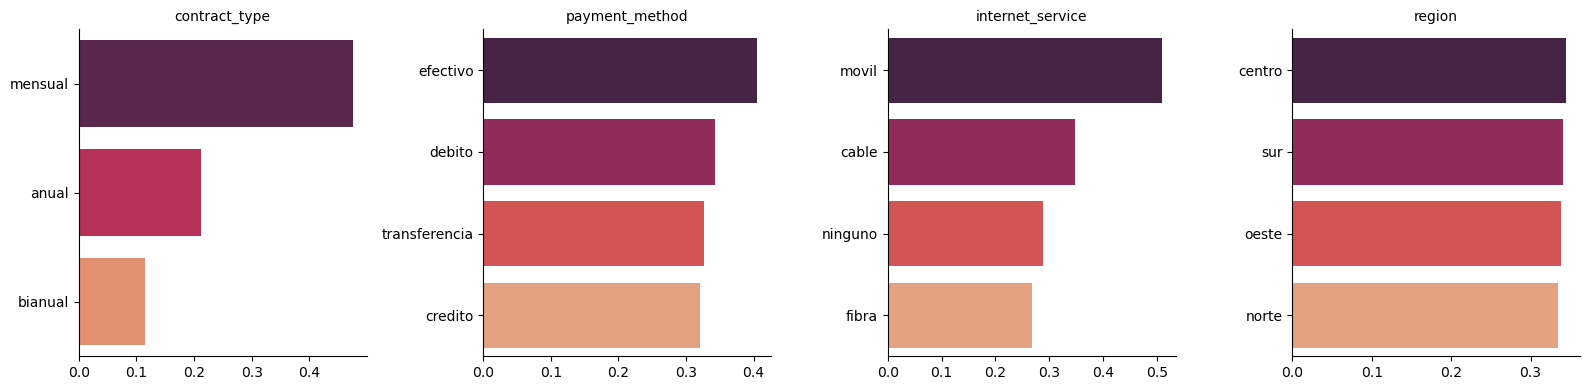

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt


# Configuramos una cuadrícula automática basada en el número de columnas
g = sns.FacetGrid(df.melt(id_vars='churn', value_vars=cols_cat), 
                  col='variable', col_wrap=4, sharex=False, sharey=False, height=4)

# Función para procesar y graficar cada categoría
def plot_churn(data, **kwargs):
    top8 = data.groupby('value')['churn'].mean().sort_values(ascending=False).head(8).reset_index()
    sns.barplot(data=top8, x='churn', y='value', hue='value', palette='rocket', legend=False)

g.map_dataframe(plot_churn)
g.set_titles("{col_name}").set_axis_labels("", "")
plt.tight_layout()
plt.show()

Vemos que no hay casi diferencia entre las categorías de la variable `region`, lo que indica que la ubicación no es un factor determinante. Por el contrario, variables como `contract_type`, `payment_method` e `internet_service` muestran una alta incidencia en el churn, destacando que se dispara en contratos mensuales, servicios de internet móvil y pagos en efectivo.

## 2.2. Análisis de variables numéricas

In [92]:
df_num = df.select_dtypes(include=[np.number])
print("\n→ Estadísticas descriptivas de variables numéricas:")
display(df_num.describe().T)


→ Estadísticas descriptivas de variables numéricas:


,count,mean,std,min,25%,50%,75%,max
tenure_months,5000.0,36.407200,20.839776,1.0,18.0000,36.000,55.0000,72.00
monthly_charge,5000.0,65.273282,17.963425,15.0,53.0600,64.965,77.3625,127.17
total_charges,5000.0,2371.156582,1555.943231,50.0,1100.3575,2162.810,3432.6575,9083.06
support_tickets,5000.0,1.710400,1.304788,0.0,1.0000,2.000,2.0000,8.00
late_payments,5000.0,0.697000,0.843880,0.0,0.0000,0.000,1.0000,5.00
avg_monthly_usage_gb,5000.0,120.528458,49.745297,5.0,86.5050,120.030,154.1000,324.40
has_streaming,5000.0,0.668000,0.470978,0.0,0.0000,1.000,1.0000,1.00
has_security_pack,5000.0,0.539800,0.498463,0.0,0.0000,1.000,1.0000,1.00
num_products,5000.0,2.516400,1.111746,1.0,2.0000,3.000,4.0000,4.00
customer_age,5000.0,47.825800,17.615684,18.0,32.0000,48.000,63.0000,78.00


Text(0.5, 1.0, 'Matriz de Correlación')

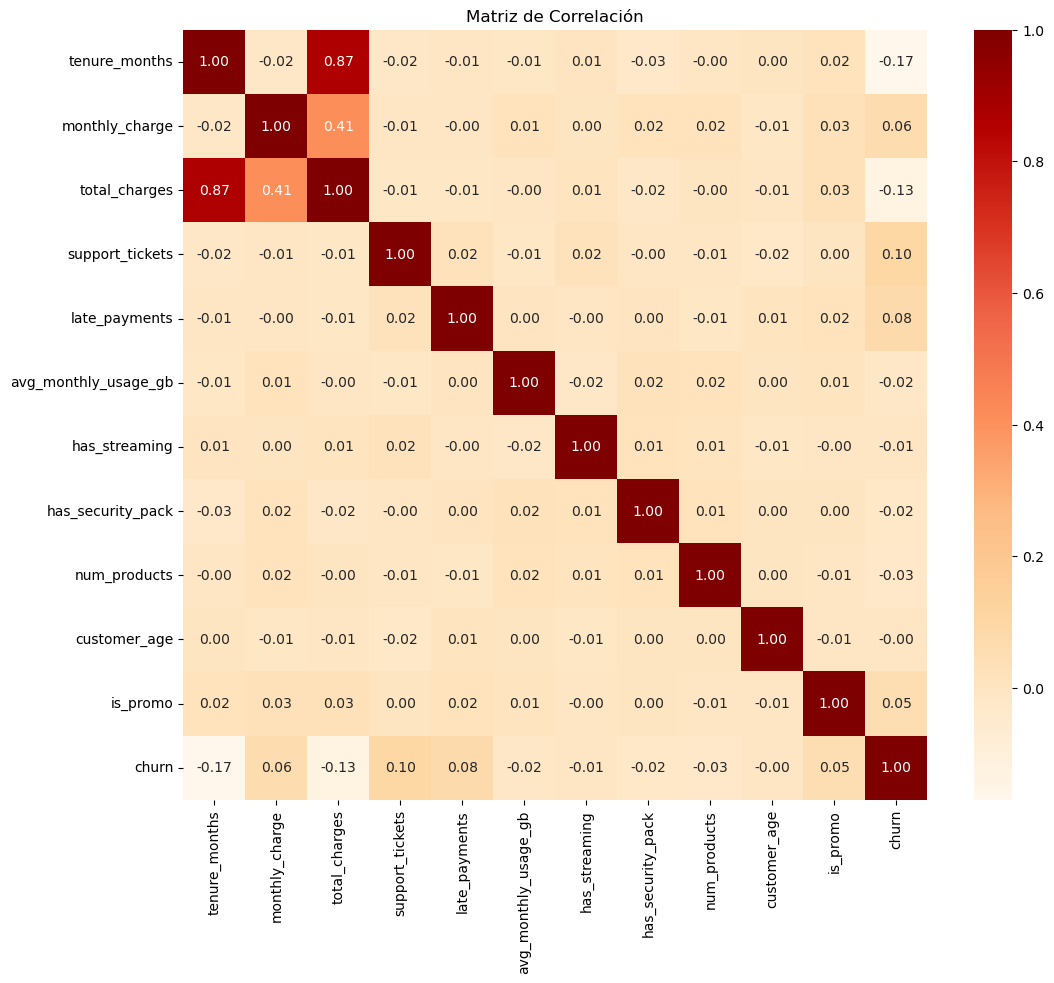

In [93]:
corr = df_num.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='OrRd', cbar=True)
plt.title("Matriz de Correlación")

Se observa una fuerte correlación entre tenure_months y total_charges (0.87), lo que indica redundancia de información. Respecto al churn, la antigüedad (tenure_months) es el principal factor de retención (-0.17), mientras que los tickets de soporte (support_tickets) son el mayor indicador de fuga (0.10). El resto de las variables no presentan una relación lineal relevante con el abandono.

<Axes: >

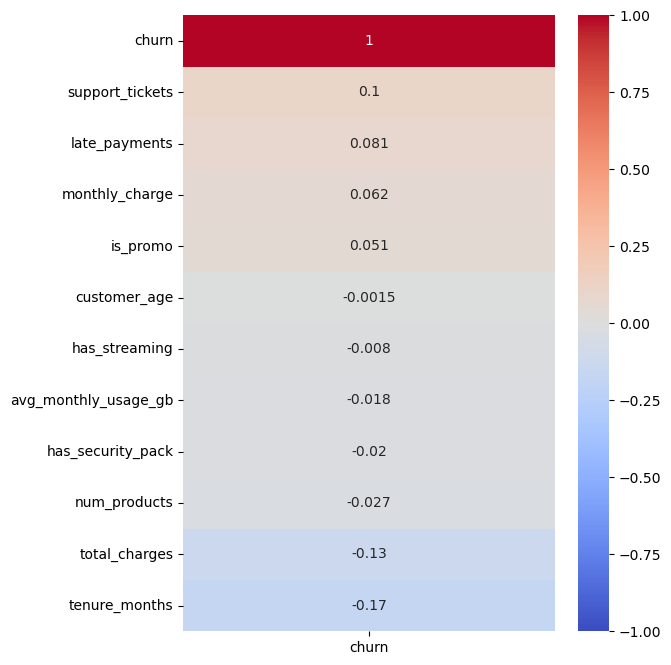

In [94]:
# Correlación con churn

plt.figure(figsize=(6,8))
sns.heatmap(
    corr[["churn"]].sort_values(by="churn", ascending=False),
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

Me gustaría ver ahora relaciones no lineales que puedan establecerse con respecto al churn. Vamos a ver que importancia tienen las variables para predecir churn en un Random Forest

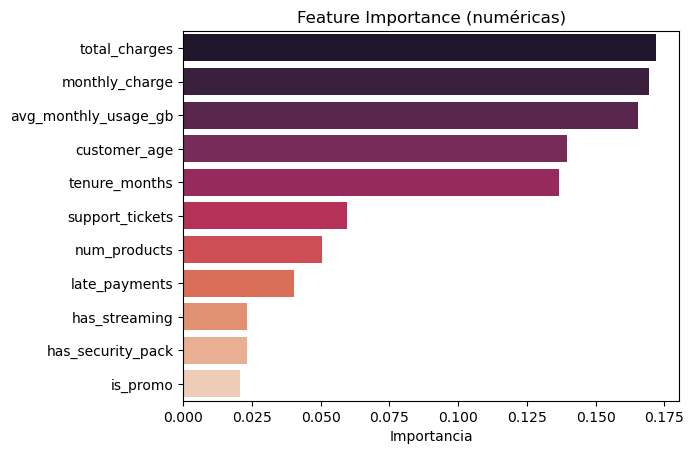

In [95]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# solo numéricas
X = df.select_dtypes(include='number').drop(columns='churn')
y = df['churn']

# modelo
model = RandomForestClassifier(random_state=42)
model.fit(X, y)

# importance
imp = pd.Series(model.feature_importances_, index=X.columns)\
        .sort_values(ascending=False)

# gráfico
sns.barplot(x=imp.values, y=imp.index, hue=imp.index, palette='rocket', legend=False)
plt.title("Feature Importance (numéricas)")
plt.xlabel("Importancia")
plt.ylabel("")
plt.show()

## 2.3. Comprobación visual Outliers (Tukey)

<Axes: >

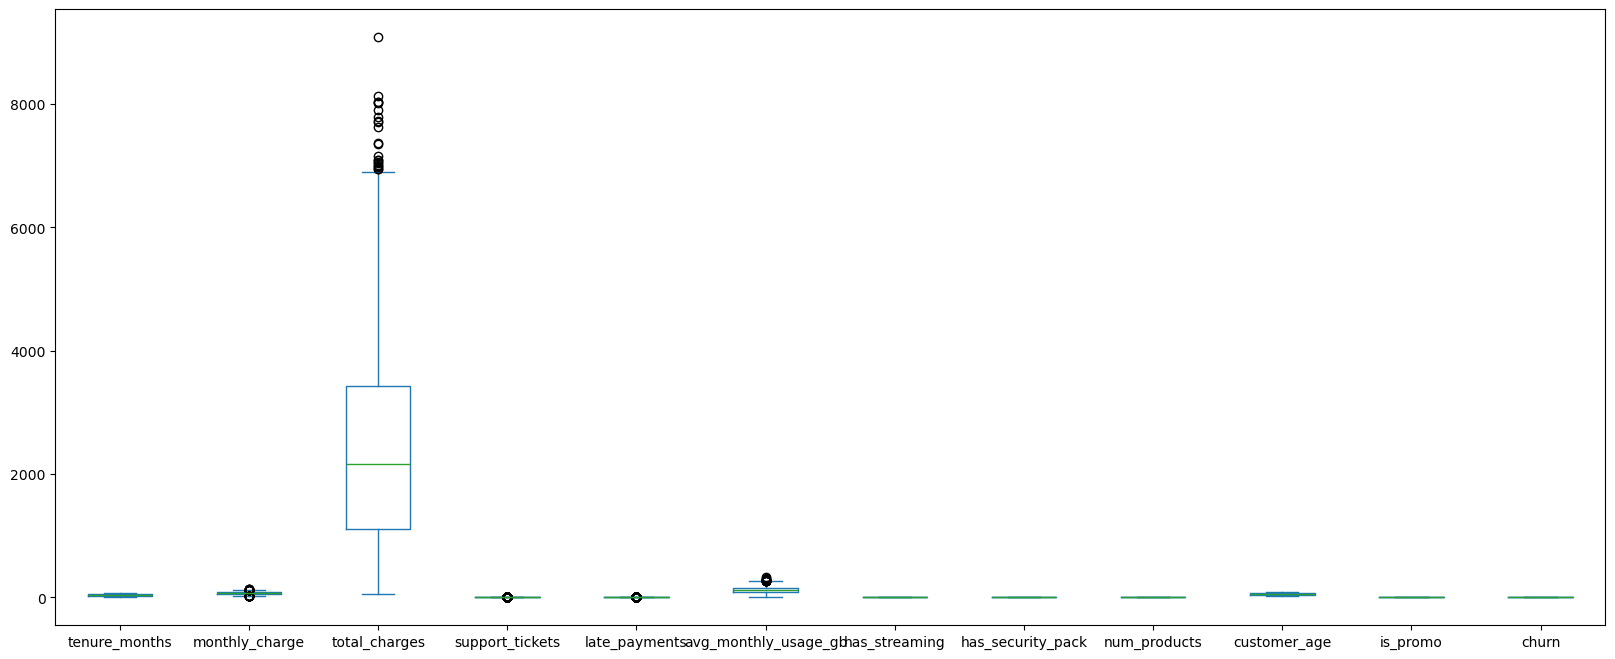

In [96]:
#df_num = df.select_dtypes("number")
df_num.plot(kind="box", figsize=(20, 8))

In [97]:
df_num[['monthly_charge', 'total_charges', 'support_tickets', 'late_payments', 'avg_monthly_usage_gb' ]].describe()

,monthly_charge,total_charges,support_tickets,late_payments,avg_monthly_usage_gb
count,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000
mean,65.273282,2371.156582,1.710400,0.69700,120.528458
std,17.963425,1555.943231,1.304788,0.84388,49.745297
min,15.000000,50.000000,0.000000,0.00000,5.000000
25%,53.060000,1100.357500,1.000000,0.00000,86.505000
50%,64.965000,2162.810000,2.000000,0.00000,120.030000
75%,77.362500,3432.657500,2.000000,1.00000,154.100000
max,127.170000,9083.060000,8.000000,5.00000,324.400000


Es necesario analizar `total_charges` por su gran asimetría

# 3. Feature Insights


## Análisis variable Total Charges

In [98]:
df['total_charges'].describe()

count    5000.000000
mean     2371.156582
std      1555.943231
min        50.000000
25%      1100.357500
50%      2162.810000
75%      3432.657500
max      9083.060000
Name: total_charges, dtype: float64

<Axes: >

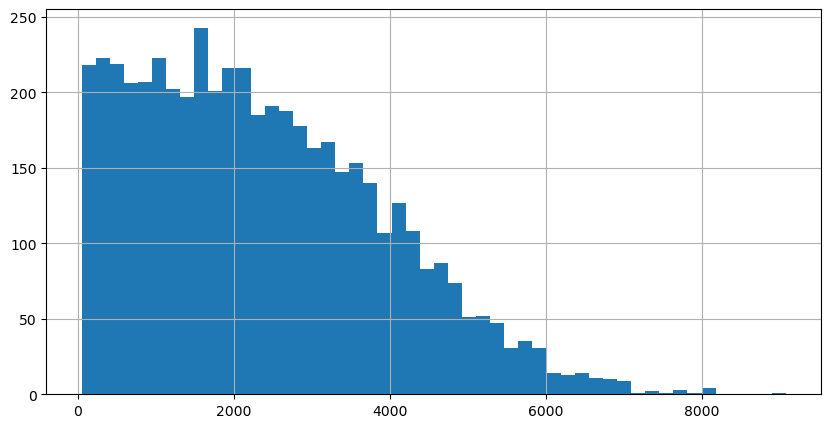

In [99]:
df['total_charges'].hist(bins=50, figsize=(10, 5))

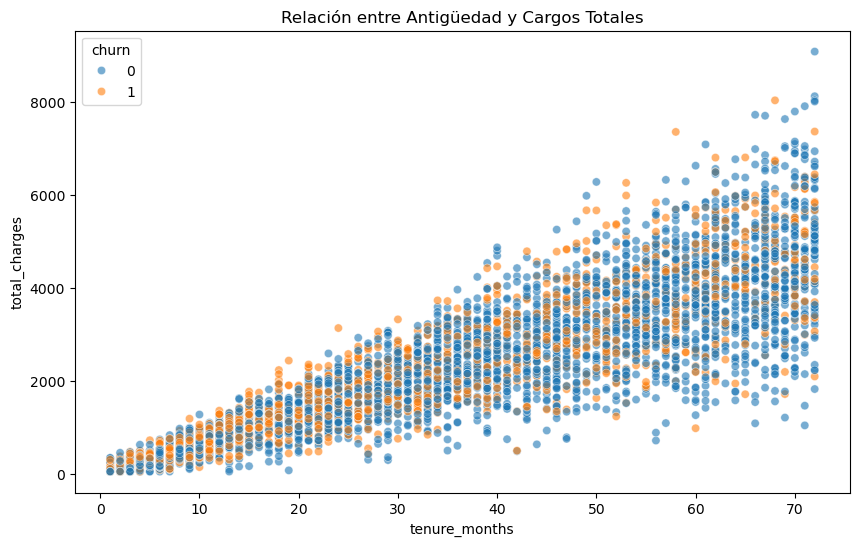

In [100]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='tenure_months', y='total_charges', hue='churn', alpha=0.6)
plt.title('Relación entre Antigüedad y Cargos Totales')
plt.show()

La relación es muy lineal, total_charges es casi una "copia" de tenure_months. Lo que tiene sentido dado que a mayor cantidad de meses en la empresa, mayor cantidad de cargas totales. 

C:\Users\Nico\AppData\Local\Temp\ipykernel_11024\501563891.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='churn', y='total_charges', palette='Set2')


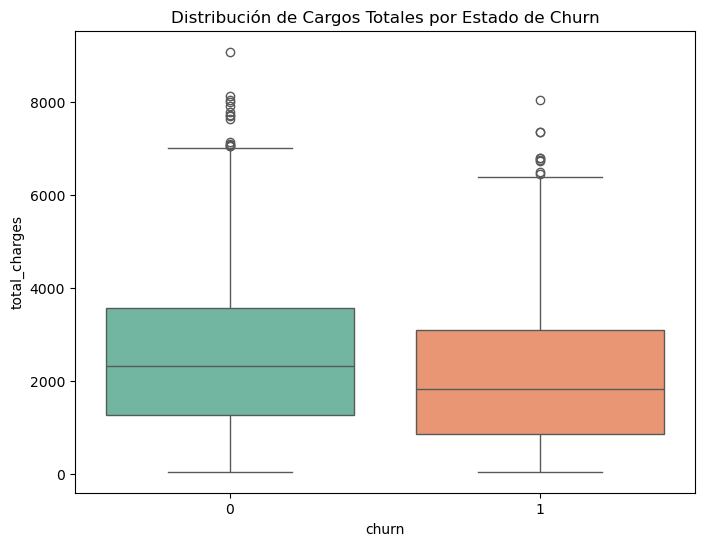

In [101]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='churn', y='total_charges', palette='Set2')
plt.title('Distribución de Cargos Totales por Estado de Churn')
plt.show()

muy parecidos, pero churn 0 tiene valores más altos (clientes Altos o VIP)

Dado que la variable total_charges presenta una asimetría extrema, con valores que triplican el promedio general, optamos por transformarla en categorías (Bajo, Medio, Alto, VIP).

Esta decisión se tomó para evitar que los valores excesivamente altos distorsionen el modelo y afecten la precisión de los resultados. Al pasar los datos a categorías, eliminamos el ruido de los valores atípicos pero conservamos la información clave sobre el nivel de consumo de cada cliente.

In [102]:
# Definimos los cortes exactos de tus cuartiles
q1 = df['total_charges'].quantile(0.25)
q2 = df['total_charges'].quantile(0.50)
q3 = df['total_charges'].quantile(0.75)

# Función de segmentación
def segmentar_total_charges(x):
    if x <= q1: return 'Bajo'
    if x <= q2: return 'Medio-Bajo'
    if x <= q3: return 'Medio-Alto'
    return 'Alto/VIP'

# Aplicar al dataframe
df['total_charges_cat'] = df['total_charges'].apply(segmentar_total_charges)
orden = ['Bajo', 'Medio-Bajo', 'Medio-Alto', 'Alto/VIP']

C:\Users\Nico\AppData\Local\Temp\ipykernel_11024\2700745714.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='total_charges_cat', y='churn', order=orden, palette='coolwarm')


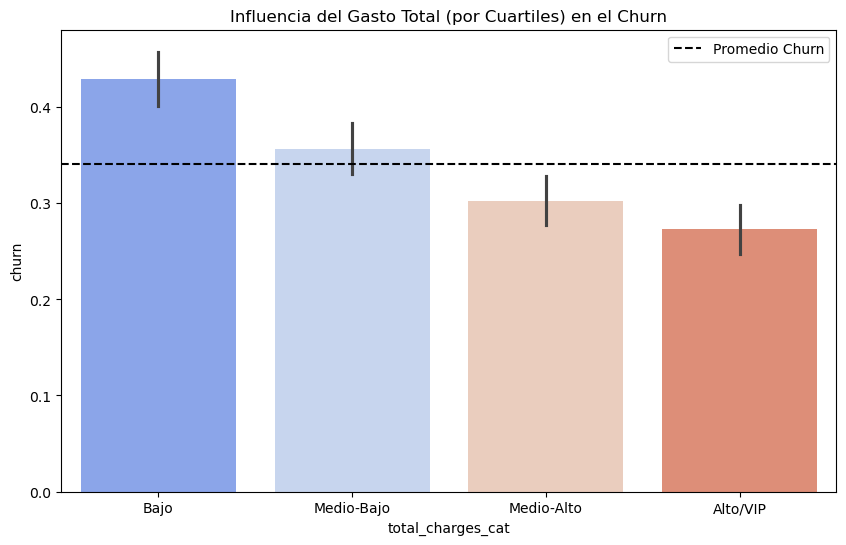

In [103]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='total_charges_cat', y='churn', order=orden, palette='coolwarm')

plt.title('Influencia del Gasto Total (por Cuartiles) en el Churn')
plt.axhline(df['churn'].mean(), color='black', linestyle='--', label='Promedio Churn')
plt.legend()
plt.show()

Muy bueno! A mayor gasto total acumulado, menor es la tasa de churn.

Nota: Eliminar total_charges del dataset

## Análisis support_tickets

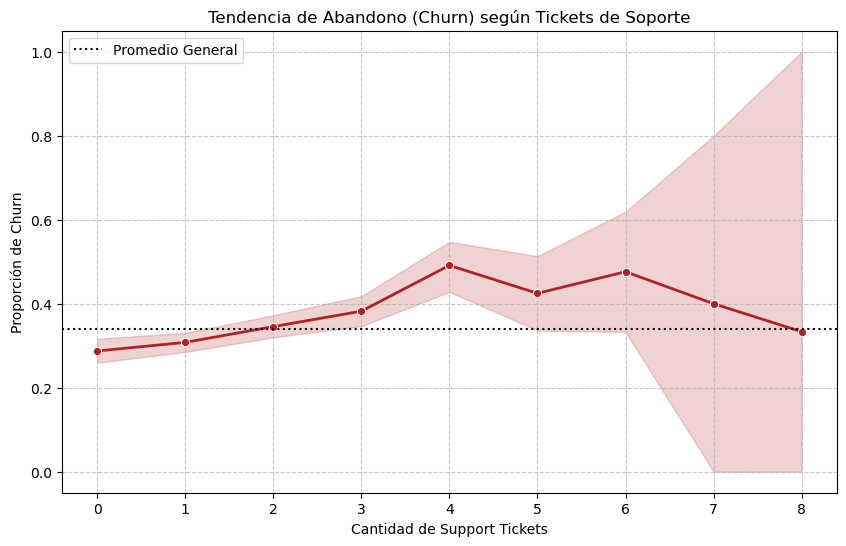

In [104]:
plt.figure(figsize=(10, 6))

# Graficamos la tendencia de Churn según la cantidad de tickets
sns.lineplot(data=df, x='support_tickets', y='churn', marker='o', color='firebrick', linewidth=2)

plt.title('Tendencia de Abandono (Churn) según Tickets de Soporte')
plt.xlabel('Cantidad de Support Tickets')
plt.ylabel('Proporción de Churn')
plt.grid(True, linestyle='--', alpha=0.7)

# Añadimos la línea del promedio general para comparar
plt.axhline(df['churn'].mean(), color='black', linestyle=':', label='Promedio General')
plt.legend()

plt.show()

In [105]:
df['support_tickets'].value_counts()

support_tickets
1    1536
2    1366
0     894
3     756
4     285
5     113
6      42
7       5
8       3
Name: count, dtype: int64

In [106]:
# Creamos una copia para no perder la original por ahora
df['tickets_grouped'] = df['support_tickets'].copy()

# Agrupamos todo lo que sea 5 o más
df.loc[df['tickets_grouped'] >= 5, 'tickets_grouped'] = 5

# Verificamos la nueva distribución
print(df['tickets_grouped'].value_counts().sort_index())

tickets_grouped
0     894
1    1536
2    1366
3     756
4     285
5     163
Name: count, dtype: int64


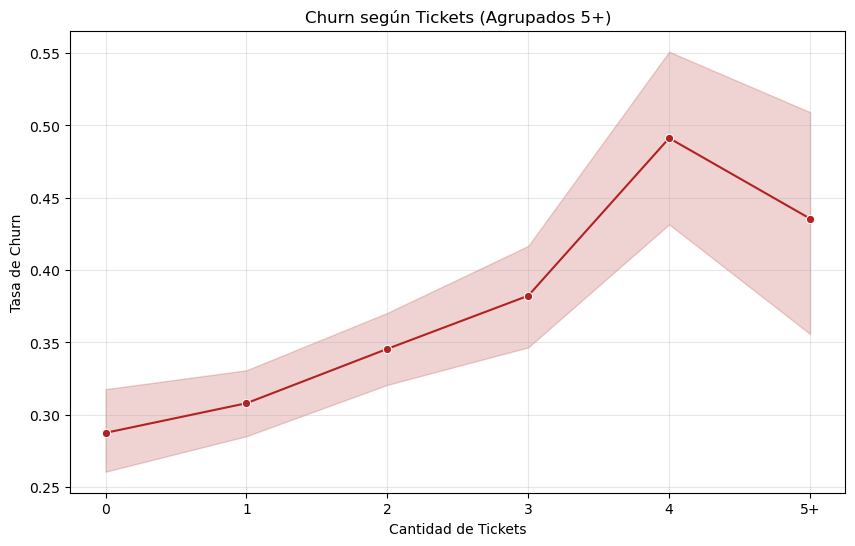

In [107]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='tickets_grouped', y='churn', marker='o', color='firebrick')

plt.title('Churn según Tickets (Agrupados 5+)')
plt.xticks(range(6), ['0', '1', '2', '3', '4', '5+'])
plt.xlabel('Cantidad de Tickets')
plt.ylabel('Tasa de Churn')
plt.grid(True, alpha=0.3)
plt.show()

Se identificó un umbral crítico de deserción al alcanzar los 4 tickets de soporte, donde la tasa de abandono se duplica respecto a los clientes sin incidencias. Se recomienda implementar un protocolo de fidelización proactiva a partir del tercer ticket para mitigar este comportamiento.

# 4. Feature engineering

In [108]:
contract_dummies = pd.get_dummies(df['contract_type'], prefix='contract_type')
df['riesgo_contrato'] = contract_dummies['contract_type_mensual'] / (df['tenure_months'] + 1)

In [109]:
cols_servicios = [col for col in df.columns if col.startswith('has_')]

df['num_servicios'] = df[cols_servicios].sum(axis=1)

In [110]:
if 'late_payments' in df.columns and 'tickets_grouped' in df.columns:
    df['cliente_problematico'] = (
        (df['late_payments'] + df['tickets_grouped']) > 0
    ).astype(int)

In [111]:
df["anchor_score"] = df["tenure_months"] * df["num_products"]

---

In [112]:
# drop variables que modificamos en el Feature Insights--> categorizadas/agrupadas
df.drop(columns=['total_charges', 'support_tickets'], inplace=True)

print(df.columns)

Index(['tenure_months', 'monthly_charge', 'late_payments',
       'avg_monthly_usage_gb', 'contract_type', 'payment_method',
       'internet_service', 'has_streaming', 'has_security_pack',
       'num_products', 'region', 'customer_age', 'is_promo', 'churn',
       'total_charges_cat', 'tickets_grouped', 'riesgo_contrato',
       'num_servicios', 'cliente_problematico', 'anchor_score'],
      dtype='str')


---

In [113]:
df.groupby('tenure_months')['churn'].mean()

tenure_months
1     0.500000
2     0.562500
3     0.454545
4     0.507042
5     0.486111
        ...   
68    0.250000
69    0.150000
70    0.191011
71    0.225352
72    0.216216
Name: churn, Length: 72, dtype: float64

In [114]:
X = df[['tenure_months']]
y = df['churn']

tree = DecisionTreeClassifier(max_leaf_nodes=5, min_samples_leaf=0.05)
tree.fit(X, y)

thresholds = tree.tree_.threshold
print(thresholds)

[33.5  7.5 52.5 -2.  18.5 -2.  -2.  -2.  -2. ]


In [115]:
bins = [0] + sorted([t for t in thresholds if t > 0]) + [df['tenure_months'].max()]

df['tenure_bin'] = pd.cut(df['tenure_months'], bins=bins)

<Axes: xlabel='tenure_months', ylabel='churn'>

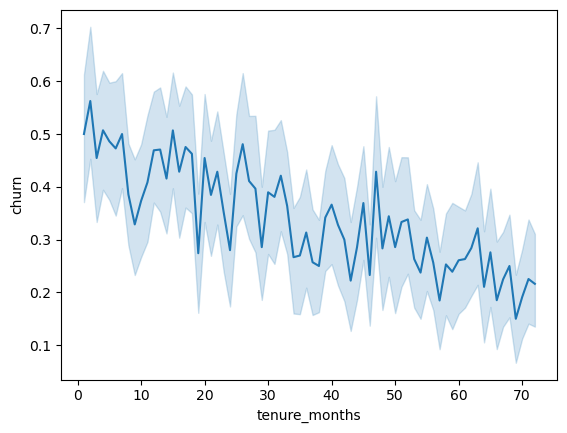

In [116]:
sns.lineplot(
    data=df.sort_values('tenure_months'),
    x='tenure_months',
    y='churn'
)

In [117]:
df['tenure_bin'] = df['tenure_bin'].cat.codes

In [118]:
df = df.drop(columns = 'tenure_months')

In [119]:
df.groupby('tenure_bin')['churn'].mean()

tenure_bin
0    0.497863
1    0.428571
2    0.380548
3    0.304382
4    0.240845
Name: churn, dtype: float64

# 5. Data Preprocessing


In [120]:
# --- A. Ordinal Encoding (Jerarquía de gasto acumulado) ---
orden_gasto = ['Bajo', 'Medio-Bajo', 'Medio-Alto', 'Alto/VIP']
#orden_gasto = ['Alto/VIP', 'Medio-Alto', 'Medio-Bajo', 'Bajo']
encoder_ord = OrdinalEncoder(categories=[orden_gasto])

df['total_charges_cat'] = encoder_ord.fit_transform(df[['total_charges_cat']])

# --- B. One-Hot Encoding (Variables sin orden jerárquico) ---
nominales = ['contract_type', 'payment_method', 'internet_service', 'region']
df = pd.get_dummies(df, columns=nominales, drop_first=True)

In [121]:
num_cols = [
    'monthly_charge',
    'avg_monthly_usage_gb',
    'customer_age',
    'num_products',
    'tickets_grouped',
    'riesgo_contrato',
    'late_payments',
    'anchor_score'
]

In [122]:
# 1. Primero separamos X e y
X = df.drop(columns=['churn']) 
y = df['churn']

# 2. Hacemos el split (usando tu random_state 123)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y
)

# 4. Inicializamos el scaler
scaler = StandardScaler()

# 5. AJUSTAMOS Y TRANSFORMAMOS el Train
# Aquí el scaler aprende la media y desviación SOLO de los datos de entrenamiento
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# 6. SOLO TRANSFORMAMOS el Test
# Usamos la info que aprendió del Train (no calculamos nada nuevo del Test)
X_test[num_cols] = scaler.transform(X_test[num_cols])

# 6. Modelos

## 6.1. Modelo Baseline

c:\Users\Nico\anaconda3\envs\proyecto_ml\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:53:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Tabla de Comparación de Baseline ---
                 Model  Accuracy  F1-Score   ROC-AUC
0  Logistic Regression     0.750  0.565972  0.800316
1        Random Forest     0.718  0.496429  0.762284
2              XGBoost     0.706  0.522727  0.731889


C:\Users\Nico\AppData\Local\Temp\ipykernel_11024\136306875.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ROC-AUC', y='Model', data=df_baseline, palette='viridis')


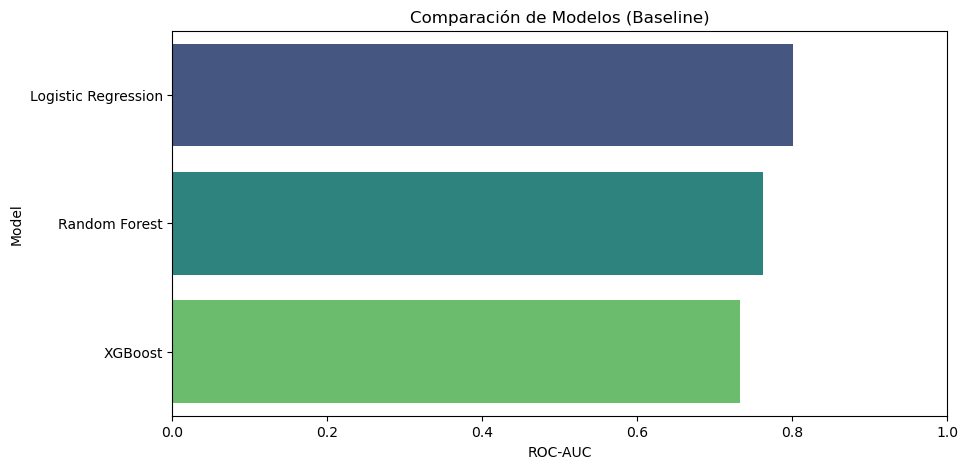

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# 4. Entrenamiento y recolección de métricas
results_list = []

for name, model in models.items():
    # Usamos los datos escalados para todos por consistencia
    model.fit(X_train, y_train)
    
    # Predicciones
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    
    # Guardar métricas
    results_list.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "F1-Score": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, probs)
    })

# 5. Visualización de resultados
df_baseline = pd.DataFrame(results_list).sort_values(by="ROC-AUC", ascending=False)
print("\n--- Tabla de Comparación de Baseline ---")
print(df_baseline)

# Gráfico rápido
plt.figure(figsize=(10, 5))
sns.barplot(x='ROC-AUC', y='Model', data=df_baseline, palette='viridis')
plt.title('Comparación de Modelos (Baseline)')
plt.xlim(0, 1)
plt.show()

Como modelo baseline optamos por elegir la Regresión Logística. Pero nos parece interesante probar si es posible optimizar un algoritmo no lineal (Random Forest) para mejorar el resultado de la predicción. 

### 6.1.1. Random Forest 

In [142]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# 1. Definir el modelo base
rf = RandomForestClassifier(random_state=42, class_weight='balanced')  # balanceamos por la clase desbalanceada

# 2. Espacio de hiperparámetros (rangos sugeridos para no saturar)
param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'bootstrap': [True]
}

# 3. Configurar RandomizedSearchCV
# n_iter=5 para que pruebe solo 5 combinaciones aleatorias (muy rápido)
# cv=3 para validación cruzada ligera
random_search = RandomizedSearchCV(
    estimator=rf, 
    param_distributions=param_dist, 
    n_iter=5, 
    cv=3, 
    n_jobs=-1, 
    scoring='f1',
    random_state=42
)

# 4. Ajustar el modelo
random_search.fit(X_train, y_train)

# Resultados
print(f"Mejores parámetros: {random_search.best_params_}")
print(f"Mejor f1-score: {random_search.best_score_}")

# El mejor modelo ya entrenado
best_rf = random_search.best_estimator_

Mejores parámetros: {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 10, 'bootstrap': True}
Mejor f1-score: 0.5708216699428228


Aunque supere el f1-score levemente al modelo baseline de logistic regresion, nos parece mejor optar por este último. 

## 6.2. Modelo elegido: Regresión Logística

In [191]:
lr_tuned = LogisticRegression(
    penalty="l1", solver="saga", C=0.5,
    class_weight={0: 1, 1: 1.65},
    max_iter=1000, random_state=42
)
lr_tuned.fit(X_train, y_train)
y_pred = lr_tuned.predict(X_test)
y_prob = lr_tuned.predict_proba(X_test)[:, 1]


print("\n" + "="*50)
print("Resultados del modelo")
print("="*50)
print(classification_report(y_test, y_pred, target_names=["No churn", "Churn"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")


Resultados del modelo
              precision    recall  f1-score   support

    No churn       0.83      0.75      0.79       660
       Churn       0.59      0.71      0.65       340

    accuracy                           0.74      1000
   macro avg       0.71      0.73      0.72      1000
weighted avg       0.75      0.74      0.74      1000

ROC-AUC: 0.8005


¿Todas las variables son relevantes para el modelo?

In [187]:
#Selección de Features

selector = SelectFromModel(
    LogisticRegression(penalty='l1', solver='liblinear', C=0.3)
)

selector.fit(X_train, y_train)

selected_features = X_train.columns[selector.get_support()]
X_selected = X_train[selected_features]
variables =X_selected.columns

X_train_model = X_train[variables]
X_test_model = X_test[X_train_model.columns]

print(f'Variables df original: {df.shape[1]}')
print(f'Variables seleccionadas: {X_train_model.shape[1]}')


print(f"\nVariables seleccionadas:\n {X_train_model.columns.tolist()}")

Variables df original: 27
Variables seleccionadas: 22

Variables seleccionadas:
 ['monthly_charge', 'late_payments', 'avg_monthly_usage_gb', 'has_security_pack', 'num_products', 'is_promo', 'total_charges_cat', 'tickets_grouped', 'riesgo_contrato', 'num_servicios', 'cliente_problematico', 'anchor_score', 'tenure_bin', 'contract_type_bianual', 'contract_type_mensual', 'payment_method_debito', 'payment_method_efectivo', 'internet_service_fibra', 'internet_service_movil', 'internet_service_ninguno', 'region_norte', 'region_oeste']


In [190]:
lr = LogisticRegression(
    penalty="l1", solver="saga", C=0.5,
    class_weight={0: 1, 1: 1.65},
    max_iter=1000, random_state=42
)
lr.fit(X_train_model, y_train)
y_pred = lr.predict(X_test_model)
y_prob = lr.predict_proba(X_test_model)[:, 1]


print("\n" + "="*50)
print("Resultados del modelo")
print("="*50)
print(classification_report(y_test, y_pred, target_names=["No churn", "Churn"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")


Resultados del modelo
              precision    recall  f1-score   support

    No churn       0.83      0.75      0.79       660
       Churn       0.60      0.71      0.65       340

    accuracy                           0.74      1000
   macro avg       0.71      0.73      0.72      1000
weighted avg       0.75      0.74      0.74      1000

ROC-AUC: 0.8006
